# FrozenLake Tabular Q-Learning

## 实验目标

本实验使用最经典的表格型 `Q-Learning` 求解 FrozenLake。目标不是追求复杂模型，而是把强化学习最基础的一条主线讲清楚：智能体如何通过反复与环境交互，逐步学会哪些动作更值得做，从而把随机试错变成更稳定的决策策略。

## 为什么这里选择 Q-Learning

这里不用 `PPO`、`DQN` 或其他更现代的方法，原因是 FrozenLake 本身就是一个非常适合教学的离散环境：

- 状态空间小，可以直接用一张 Q 表保存所有状态-动作价值
- 动作空间离散，不需要连续控制算法
- 环境机制直观，适合讲解探索、奖励和价值更新
- 这个实验的主要目标是教学和方法入门，而不是设备吞吐或大规模并行训练

因此，这里优先使用 `Tabular Q-Learning`，是为了把强化学习最核心的更新逻辑讲清楚。

## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是本实验没有神经网络，更新对象只是一张小型 Q 表。GPU 对这种计算几乎没有意义，并行环境也不会给这个级别的教学实验带来明显收益。这个实验的重点是把方法论讲明白，而不是尽量把算力榨满。

In [1]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [2]:
ENV_ID = "FrozenLake-v1"
NUM_EPISODES = 50000
MAX_STEPS = 100
LEARNING_RATE = 0.1
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.99985
ROLLING_WINDOW = 200
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID, is_slippery=True)
num_states = env.observation_space.n
num_actions = env.action_space.n

q_table = np.zeros((num_states, num_actions), dtype=np.float32)

## 参数选择说明

这里的参数都不是随便填的，而是和环境特征匹配：

- `NUM_EPISODES = 50000`：为了让策略更充分收敛，这里把训练回合数明显提高，减少只学到部分路径偏好的情况
- `LEARNING_RATE = 0.1`：让 Q 值逐步更新，但不过于剧烈，适合作为表格方法的稳妥起点
- `GAMMA = 0.99`：终点奖励属于长期目标，需要保持较高未来奖励权重
- `EPSILON_START = 1.0`：训练初期充分探索
- `EPSILON_END = 0.05`：训练后期仍保留少量探索，避免过早僵化
- `EPSILON_DECAY = 0.99985`：让探索衰减更慢一些，在更长训练预算下持续探索关键状态转移
- `ROLLING_WINDOW = 200`：平滑训练曲线，便于观察趋势

这些参数如果调整过激，常见后果包括：

- 学习率过大：Q 值震荡明显
- 学习率过小：收敛很慢
- 折扣因子过低：智能体只看眼前，难以学到稳定到终点的策略
- 探索衰减过快：过早陷入局部路径或失败模式

In [3]:
def epsilon_greedy_action(q_values, state, epsilon, action_space):
    if np.random.random() < epsilon:
        return action_space.sample()
    return int(np.argmax(q_values[state]))

In [4]:
epsilon = EPSILON_START
episode_rewards = []
successes = []
epsilons = []
episode_lengths = []

for episode in tqdm(range(NUM_EPISODES), desc="Q-Learning episodes"):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action = epsilon_greedy_action(q_table, state, epsilon, env.action_space)
        next_state, reward, terminated, truncated, info = env.step(action)

        best_next_q = np.max(q_table[next_state])
        td_target = reward + GAMMA * best_next_q * (1 - int(terminated or truncated))
        td_error = td_target - q_table[state, action]
        q_table[state, action] += LEARNING_RATE * td_error

        state = next_state
        total_reward += reward

        if terminated or truncated:
            episode_lengths.append(step + 1)
            break
    else:
        episode_lengths.append(MAX_STEPS)

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    epsilons.append(epsilon)
    episode_rewards.append(total_reward)
    successes.append(int(total_reward > 0))

env.close()

Q-Learning episodes:   0%|          | 0/50000 [00:00<?, ?it/s]

In [5]:
reward_series = pd.Series(episode_rewards)
success_series = pd.Series(successes)
epsilon_series = pd.Series(epsilons)

rolling_reward = reward_series.rolling(ROLLING_WINDOW).mean()
rolling_success = success_series.rolling(ROLLING_WINDOW).mean()

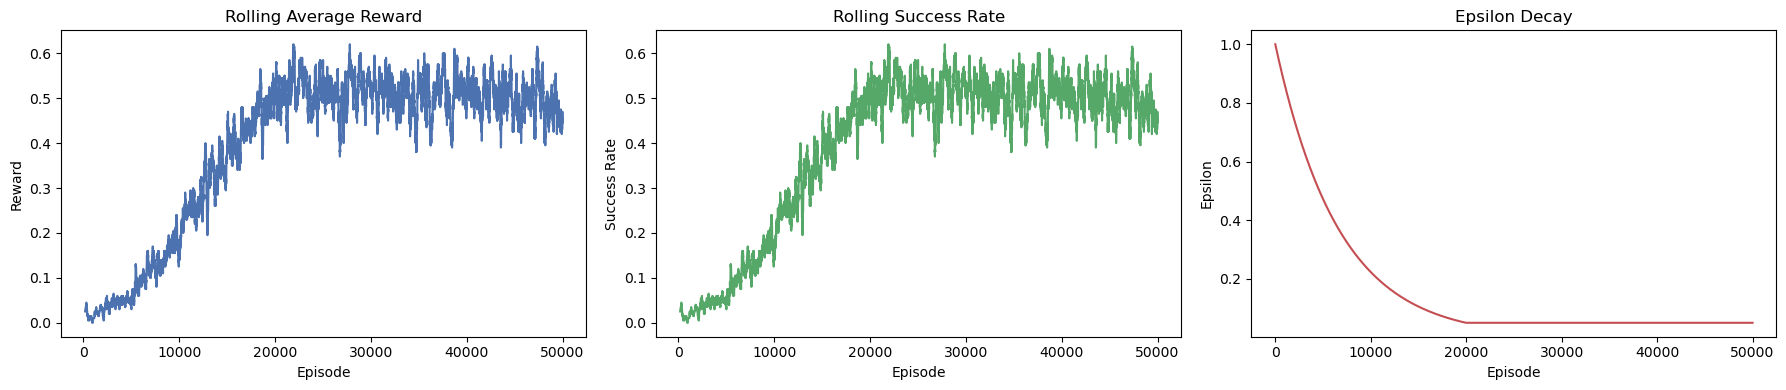

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(rolling_reward, color="#4c72b0")
axes[0].set_title("Rolling Average Reward")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")

axes[1].plot(rolling_success, color="#55a868")
axes[1].set_title("Rolling Success Rate")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Success Rate")

axes[2].plot(epsilon_series, color="#c44e52")
axes[2].set_title("Epsilon Decay")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Epsilon")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "q_learning_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

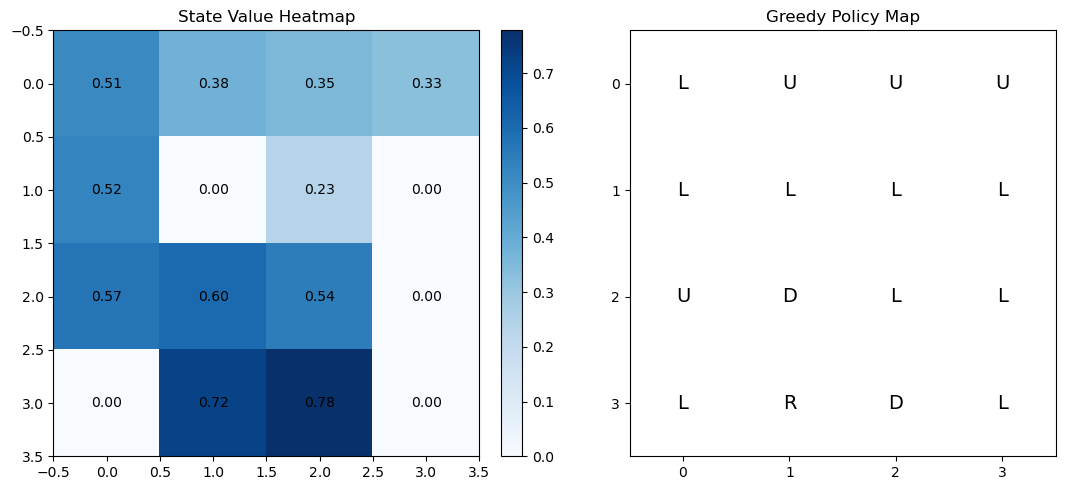

In [7]:
action_symbols = np.array(["L", "D", "R", "U"])
best_actions = action_symbols[np.argmax(q_table, axis=1)].reshape(4, 4)
state_values = np.max(q_table, axis=1).reshape(4, 4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(state_values, cmap="Blues")
axes[0].set_title("State Value Heatmap")
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f"{state_values[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(np.zeros((4, 4)), cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("Greedy Policy Map")
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, best_actions[i, j], ha="center", va="center", color="black", fontsize=14)
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "q_learning_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
metrics = pd.DataFrame(
    {
        "metric": ["overall_success_rate", "average_reward", "average_episode_length", "final_epsilon"],
        "value": [np.mean(successes), np.mean(episode_rewards), np.mean(episode_lengths), epsilon],
    }
)

metrics

,metric,value
0,overall_success_rate,0.39492
1,average_reward,0.39492
2,average_episode_length,31.17778
3,final_epsilon,0.05000


In [9]:
metrics.to_csv(RESULTS_DIR / "q_learning_metrics.csv", index=False)
pd.DataFrame(q_table).to_csv(RESULTS_DIR / "q_table.csv", index=False)

print("Final epsilon:", round(float(epsilon), 4))
print("Overall success rate:", round(float(np.mean(successes)), 4))
print("Average reward:", round(float(np.mean(episode_rewards)), 4))
print("Average episode length:", round(float(np.mean(episode_lengths)), 2))
print(f"Saved results to: {RESULTS_DIR.resolve()}")

Final epsilon: 0.05
Overall success rate: 0.3949
Average reward: 0.3949
Average episode length: 31.18
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/01-frozenlake-tabular-q-learning/results


## 结果解读

训练完成后，重点观察以下内容：

- 滚动平均奖励是否逐渐上升
- 成功率是否从接近随机水平逐步提升
- `epsilon` 是否按预期逐渐下降，说明策略在从探索过渡到利用
- 状态价值热力图是否在靠近目标区域形成更高价值
- 贪心策略图是否出现相对稳定的前进方向

如果这些现象都成立，就说明 `Q-Learning` 已经在这个小型离散环境中学到了有效策略。即使实验规模很小，它仍然完整体现了强化学习中的几个核心概念：探索、价值估计、时序差分更新，以及通过反复交互把随机行为逐步改造成更可靠策略。